# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [4]:
# Load the dataset
kart = pd.read_csv('https://raw.githubusercontent.com/ajitbubu/superKart/main/SuperKart.csv') # Replace with the actual path to your file
display(kart.head())

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

In [6]:
# Display first few rows
print("First 5 rows of the dataset:")
data.head()



First 5 rows of the dataset:


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [7]:
# Display last 5 rows
print("Last 5 rows of the dataset:")
data.tail()


Last 5 rows of the dataset:


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [8]:
# Display dataset info
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [9]:
# Display statistical summary
print("Statistical Summary:")
data.describe()


Statistical Summary:


,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


In [10]:
# Check for missing values
print("Missing Values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("No missing values found!")
print("\n" + "="*80 + "\n")

Missing Values:
Series([], dtype: int64)
No missing values found!




In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [12]:
# Check for duplicates
print(f"Number of duplicate rows: {data.duplicated().sum()}")
print("\n" + "="*80 + "\n")

# Display unique values for categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns
print("Unique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}: {data[col].nunique()} unique values")
    print(data[col].value_counts())

Number of duplicate rows: 0


Unique values in categorical columns:

Product_Id: 8763 unique values
Product_Id
FD306     1
FD6114    1
FD7839    1
FD5075    1
FD8233    1
         ..
FD1387    1
FD1231    1
FD5276    1
FD8553    1
FD6027    1
Name: count, Length: 8763, dtype: int64

Product_Sugar_Content: 4 unique values
Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64

Product_Type: 16 unique values
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64

Store

In [13]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.") #Complete the code to display the number of columns

There are 8763 rows and 12 columns.


In [14]:
# Statistical summary
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# checking for missing values in the data
data.isnull().sum() #Complete the code to compute the number of missing values.

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

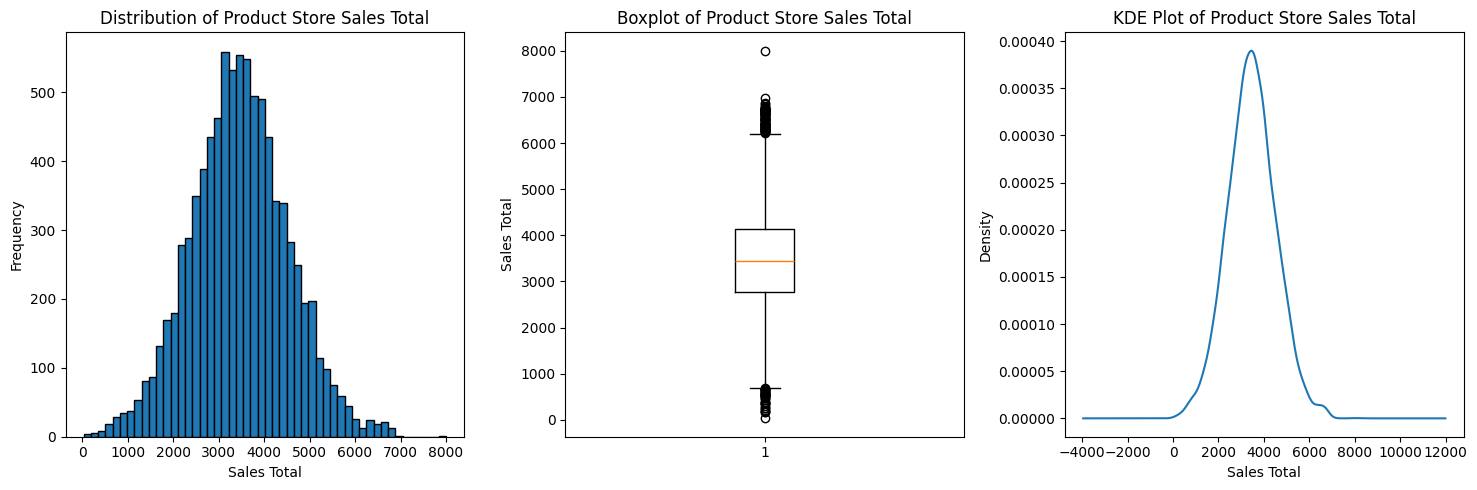


Numerical columns: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']


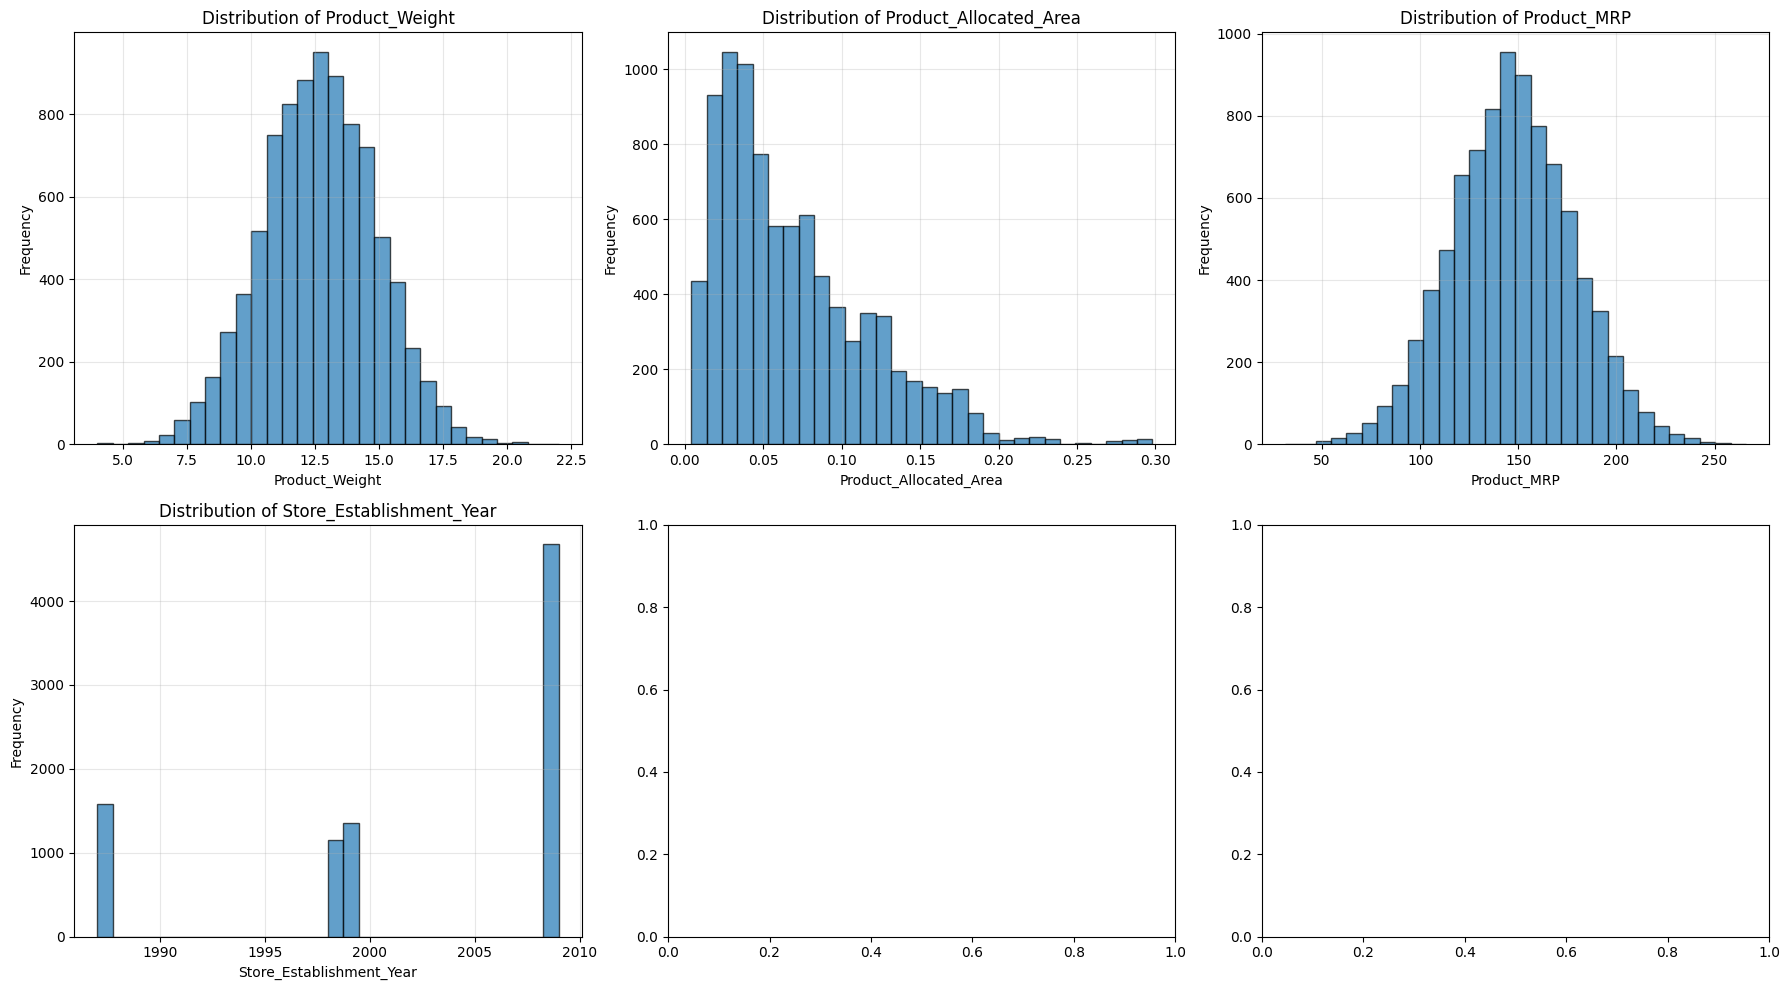


Categorical columns: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


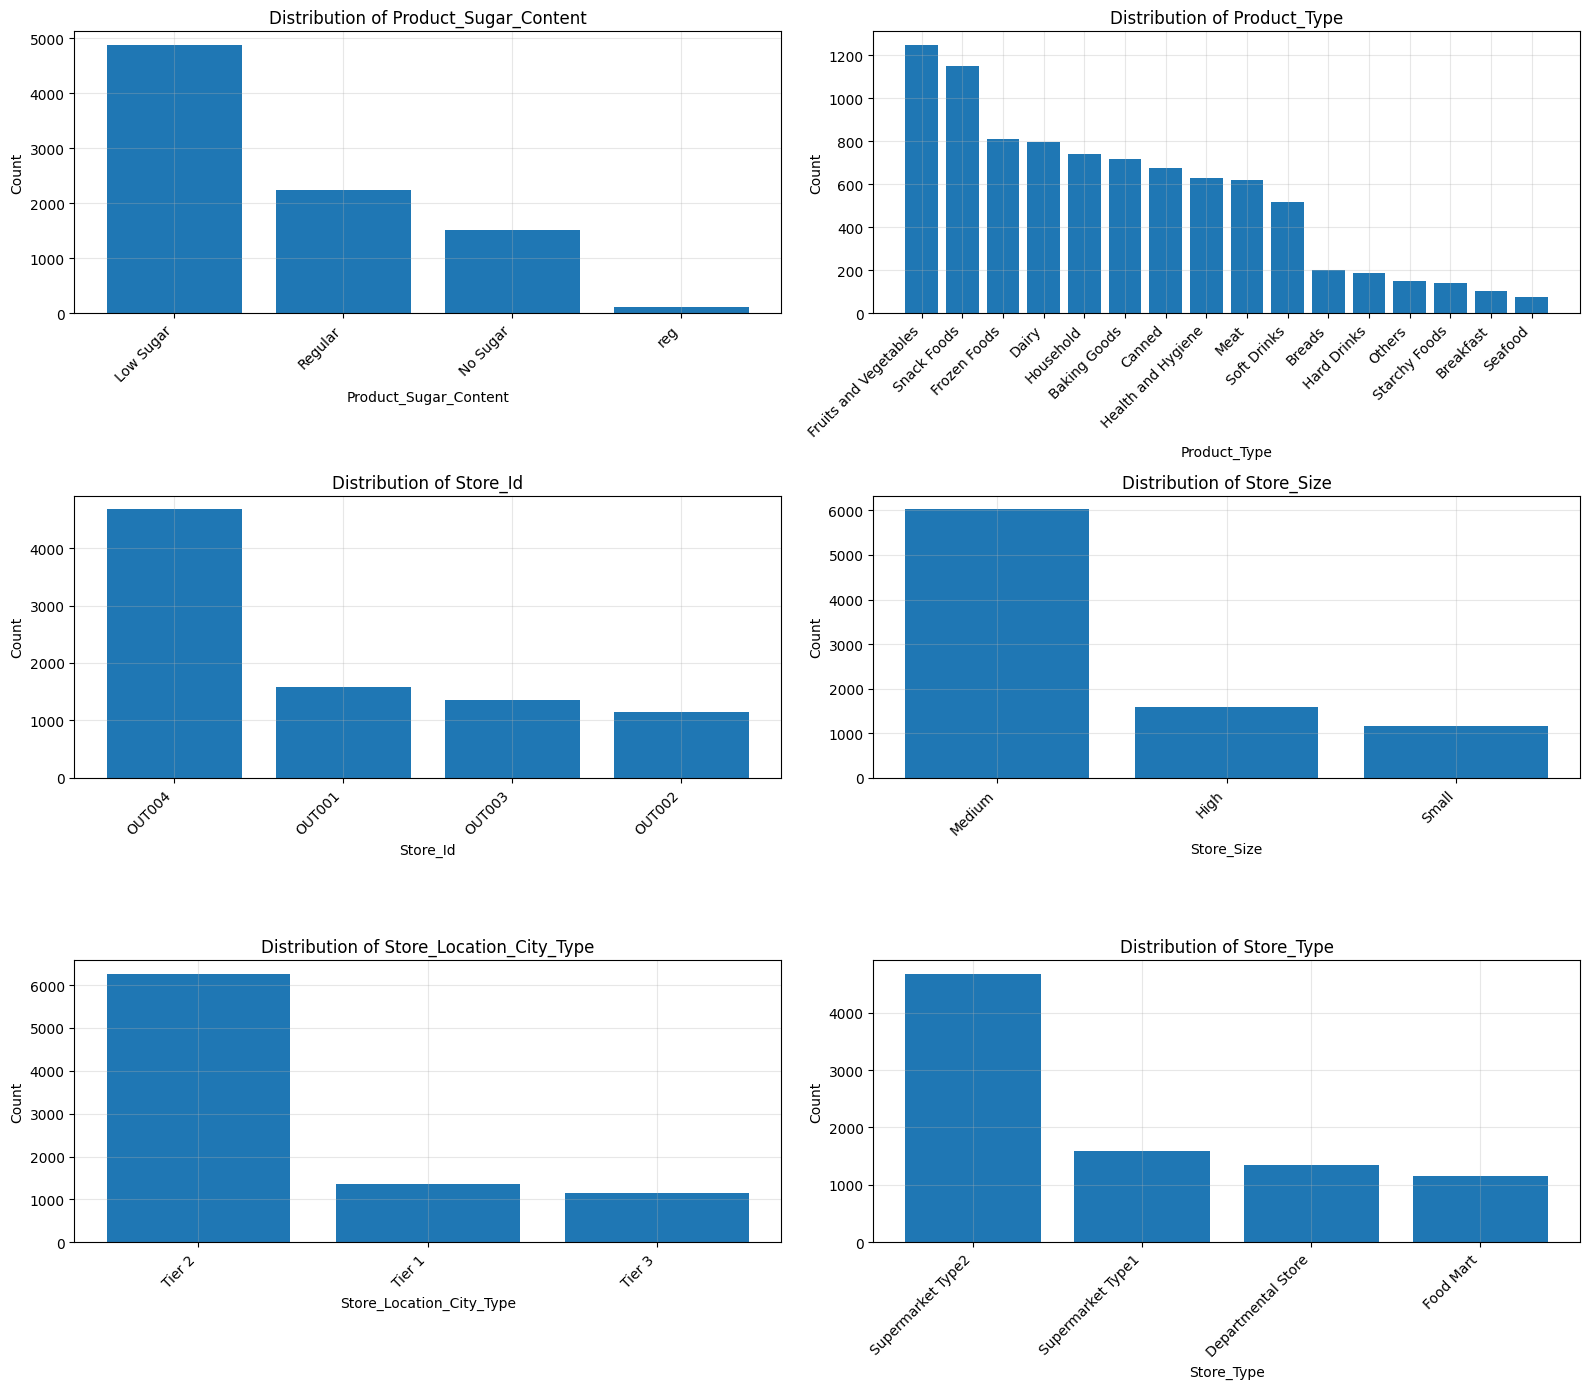

In [20]:
# Distribution of target variable
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(data['Product_Store_Sales_Total'], bins=50, edgecolor='black')
plt.xlabel('Sales Total')
plt.ylabel('Frequency')
plt.title('Distribution of Product Store Sales Total')

plt.subplot(1, 3, 2)
plt.boxplot(data['Product_Store_Sales_Total'])
plt.ylabel('Sales Total')
plt.title('Boxplot of Product Store Sales Total')

plt.subplot(1, 3, 3)
data['Product_Store_Sales_Total'].plot(kind='kde')
plt.xlabel('Sales Total')
plt.title('KDE Plot of Product Store Sales Total')

plt.tight_layout()
plt.show()

# Numerical features distribution
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('Product_Store_Sales_Total')
print(f"\nNumerical columns: {list(numerical_cols)}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(data[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Categorical features distribution
categorical_cols = data.select_dtypes(include=['object']).columns.drop('Product_Id')
print(f"\nCategorical columns: {list(categorical_cols)}")

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = data[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
plt.show()

## Bivariate Analysis

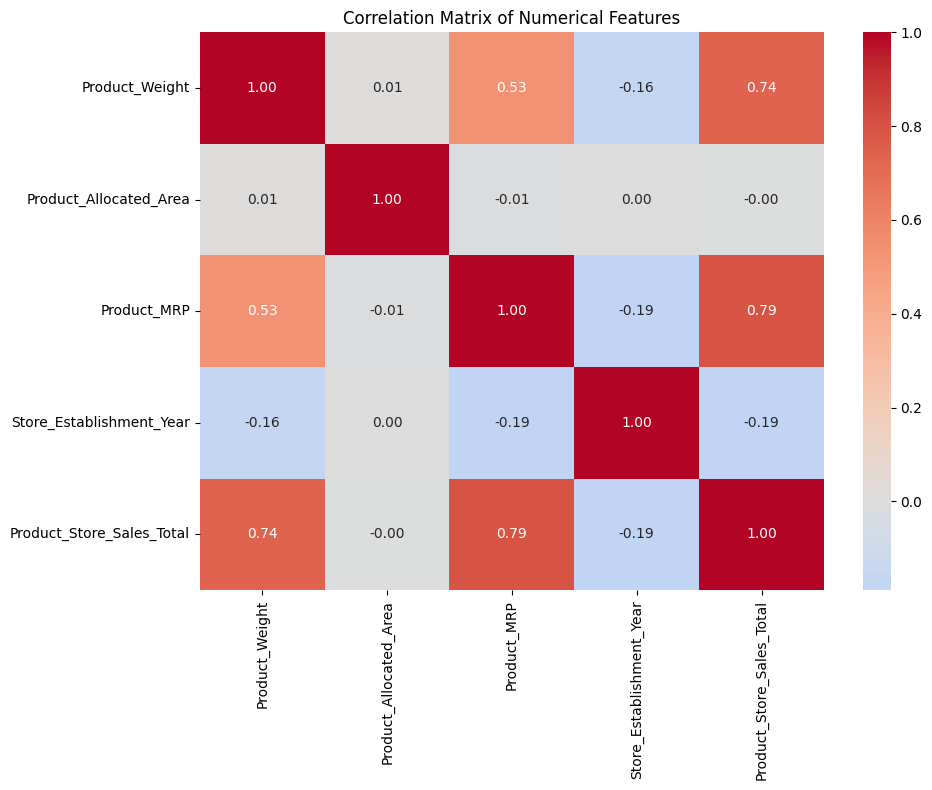

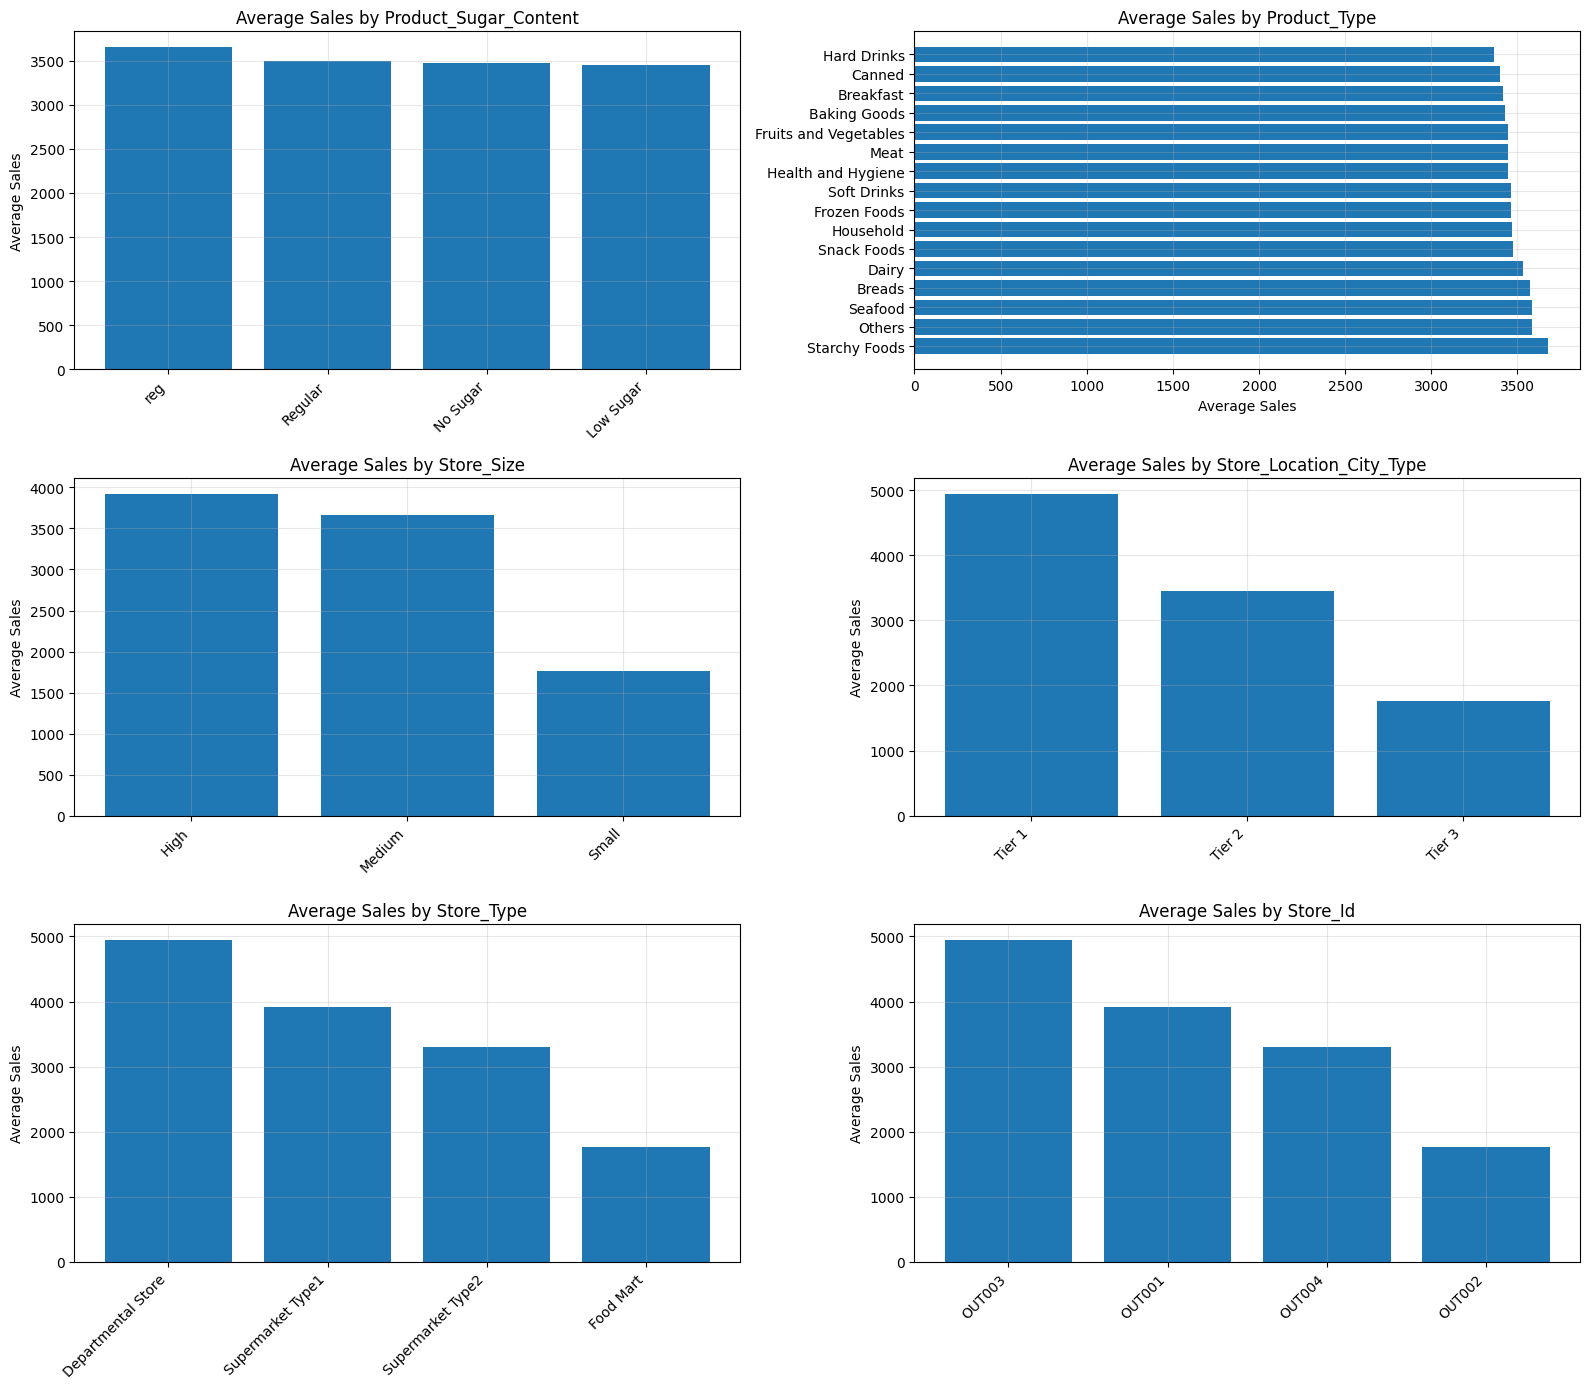

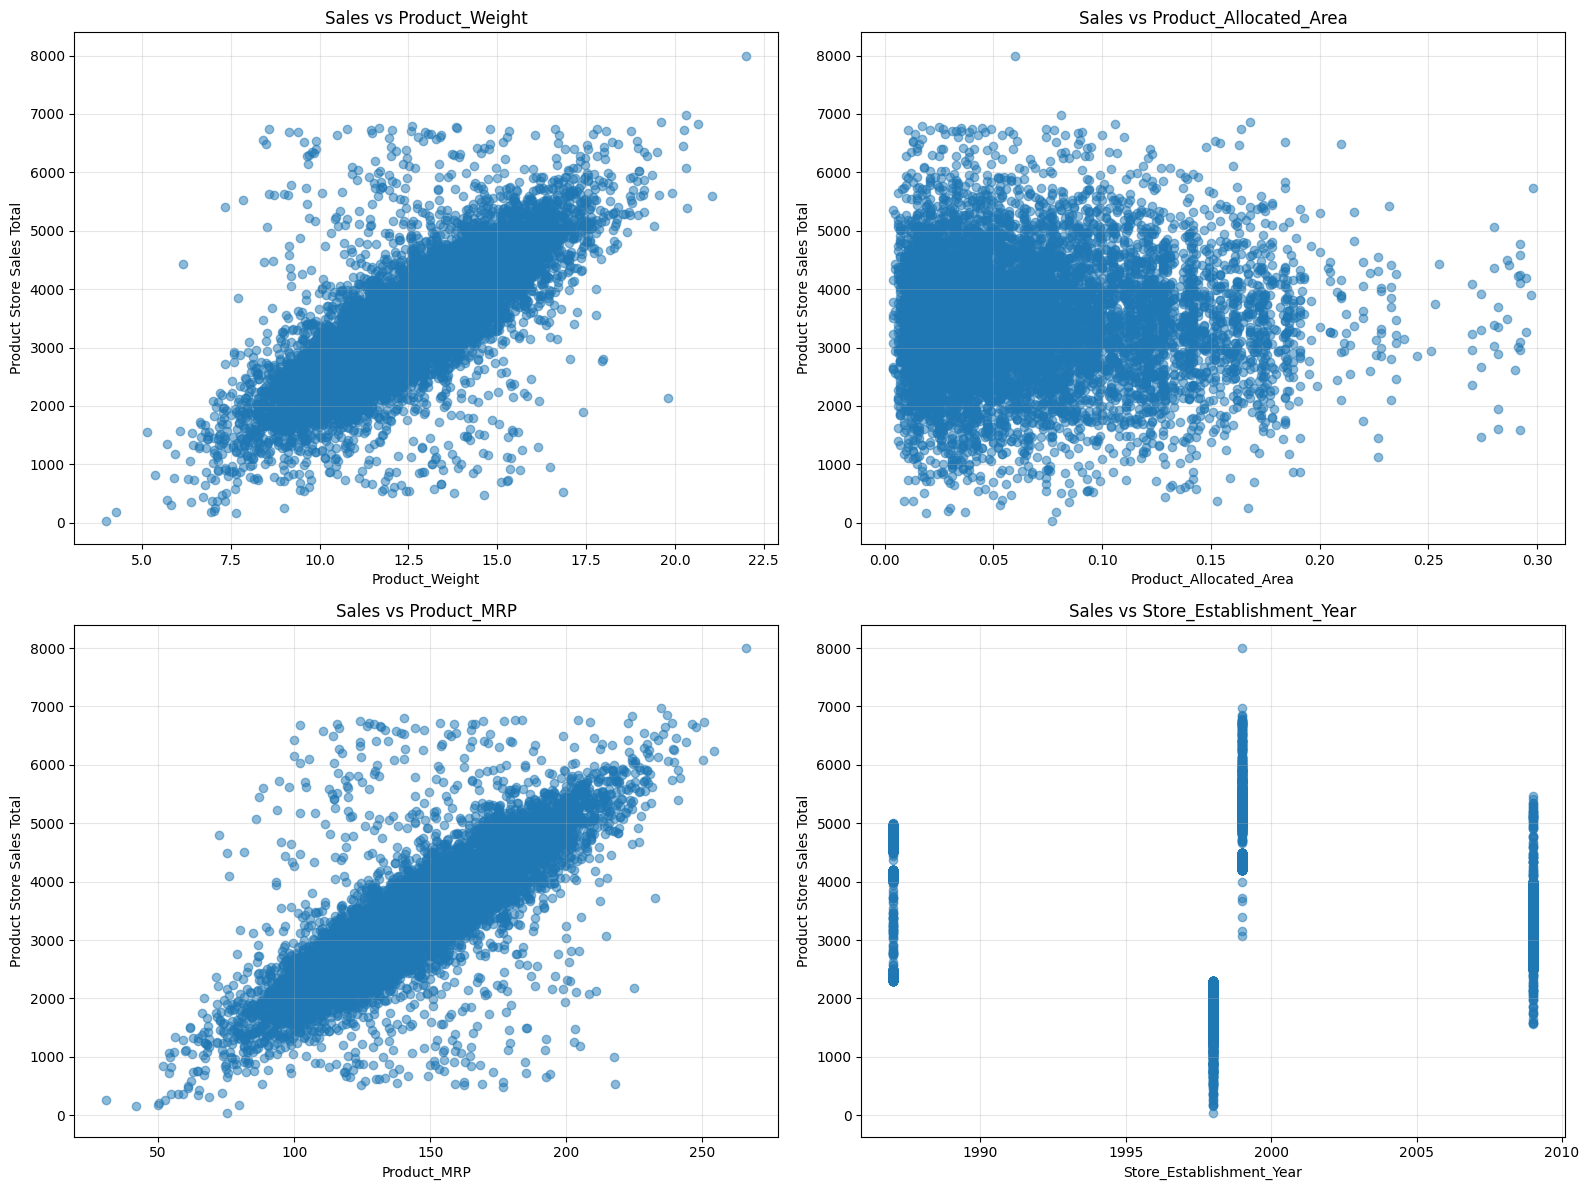

In [27]:
# Correlation analysis
plt.figure(figsize=(10, 8))
correlation_matrix = data.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Sales by categorical features
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

categorical_cols_list = ['Product_Sugar_Content', 'Product_Type', 'Store_Size',
                         'Store_Location_City_Type', 'Store_Type', 'Store_Id']

for idx, col in enumerate(categorical_cols_list):
    if col == 'Product_Type':
        avg_sales = data.groupby(col)['Product_Store_Sales_Total'].mean().sort_values(ascending=False)
        axes[idx].barh(range(len(avg_sales)), avg_sales.values)
        axes[idx].set_yticks(range(len(avg_sales)))
        axes[idx].set_yticklabels(avg_sales.index)
        axes[idx].set_xlabel('Average Sales')
    else:
        avg_sales = data.groupby(col)['Product_Store_Sales_Total'].mean().sort_values(ascending=False)
        axes[idx].bar(range(len(avg_sales)), avg_sales.values)
        axes[idx].set_xticks(range(len(avg_sales)))
        axes[idx].set_xticklabels(avg_sales.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Average Sales')
    axes[idx].set_title(f'Average Sales by {col}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plots for numerical features vs sales
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    axes[idx].scatter(data[col], data['Product_Store_Sales_Total'], alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Product Store Sales Total')
    axes[idx].set_title(f'Sales vs {col}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [28]:
# Create a copy for preprocessing
df_processed = data.copy()

# Feature Engineering: Store Age
current_year = 2024
df_processed['Store_Age'] = current_year - df_processed['Store_Establishment_Year']

# Drop unnecessary columns
columns_to_drop = ['Product_Id', 'Store_Id', 'Store_Establishment_Year']
df_processed = df_processed.drop(columns=columns_to_drop)

print(f"Shape after dropping columns: {df_processed.shape}")
print(f"\nRemaining columns: {list(df_processed.columns)}")

# Separate features and target
X = df_processed.drop('Product_Store_Sales_Total', axis=1)
y = df_processed['Product_Store_Sales_Total']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"\nCategorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Shape after dropping columns: (8763, 10)

Remaining columns: ['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total', 'Store_Age']

Features shape: (8763, 9)
Target shape: (8763,)

Categorical features: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
Numerical features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']

Training set size: 7010
Test set size: 1753


# **Model Building**

## Define functions for Model Evaluation

In [29]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost


Training Random Forest Model...

Random Forest - Training Performance:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  107.688447  40.150857   0.989774        0.989761  0.015108

Random Forest - Test Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  284.778641  107.976773   0.928924        0.928557  0.038572

Training XGBoost Model...

XGBoost - Training Performance:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  130.717444  62.113506   0.984933        0.984913  0.021446

XGBoost - Test Performance:
       RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  308.8205  137.396514   0.916417        0.915985  0.051041


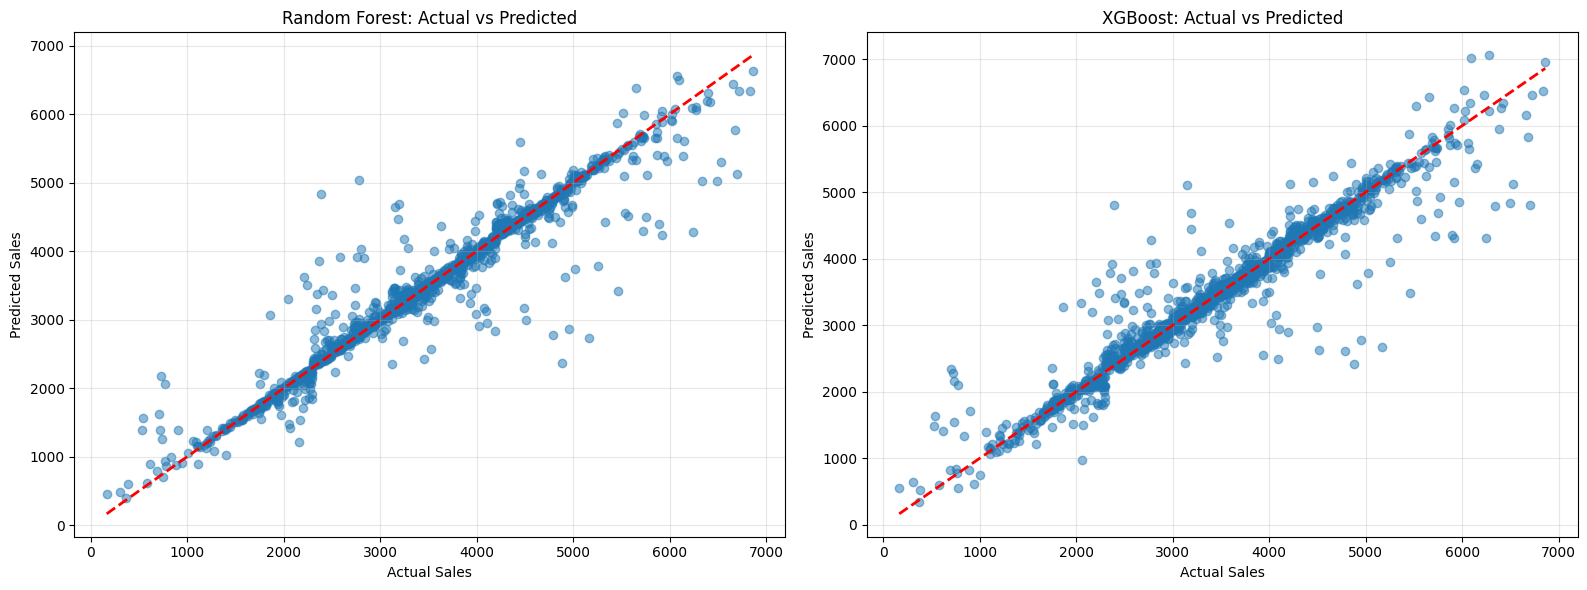

In [30]:
# Create preprocessing pipeline
preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
)

# Dictionary to store models and their performance
models = {}
performance = {}

# Model 1: Random Forest
print("\n" + "="*80)
print("Training Random Forest Model...")
print("="*80)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)
models['Random Forest'] = rf_pipeline

# Evaluate Random Forest
print("\nRandom Forest - Training Performance:")
rf_train_perf = model_performance_regression(rf_pipeline, X_train, y_train)
print(rf_train_perf)

print("\nRandom Forest - Test Performance:")
rf_test_perf = model_performance_regression(rf_pipeline, X_test, y_test)
print(rf_test_perf)

performance['Random Forest'] = {
    'train': rf_train_perf,
    'test': rf_test_perf
}

# Model 2: XGBoost
print("\n" + "="*80)
print("Training XGBoost Model...")
print("="*80)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, n_estimators=100))
])

xgb_pipeline.fit(X_train, y_train)
models['XGBoost'] = xgb_pipeline

# Evaluate XGBoost
print("\nXGBoost - Training Performance:")
xgb_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print(xgb_train_perf)

print("\nXGBoost - Test Performance:")
xgb_test_perf = model_performance_regression(xgb_pipeline, X_test, y_test)
print(xgb_test_perf)

performance['XGBoost'] = {
    'train': xgb_train_perf,
    'test': xgb_test_perf
}

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_pred = rf_pipeline.predict(X_test)
axes[0].scatter(y_test, rf_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].grid(alpha=0.3)

# XGBoost
xgb_pred = xgb_pipeline.predict(X_test)
axes[1].scatter(y_test, xgb_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].set_title('XGBoost: Actual vs Predicted')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Model Performance Improvement - Hyperparameter Tuning**

In [31]:
# Hyperparameter tuning for Random Forest
print("\n" + "="*80)
print("Hyperparameter Tuning for Random Forest...")
print("="*80)

rf_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f"\nBest parameters for Random Forest: {rf_grid_search.best_params_}")
print(f"Best R² score: {rf_grid_search.best_score_:.4f}")

# Update the model
models['Random Forest Tuned'] = rf_grid_search.best_estimator_

print("\nRandom Forest Tuned - Training Performance:")
rf_tuned_train_perf = model_performance_regression(rf_grid_search.best_estimator_, X_train, y_train)
print(rf_tuned_train_perf)

print("\nRandom Forest Tuned - Test Performance:")
rf_tuned_test_perf = model_performance_regression(rf_grid_search.best_estimator_, X_test, y_test)
print(rf_tuned_test_perf)

performance['Random Forest Tuned'] = {
    'train': rf_tuned_train_perf,
    'test': rf_tuned_test_perf
}

# Hyperparameter tuning for XGBoost
print("\n" + "="*80)
print("Hyperparameter Tuning for XGBoost...")
print("="*80)

xgb_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__subsample': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print(f"\nBest parameters for XGBoost: {xgb_grid_search.best_params_}")
print(f"Best R² score: {xgb_grid_search.best_score_:.4f}")

# Update the model
models['XGBoost Tuned'] = xgb_grid_search.best_estimator_

print("\nXGBoost Tuned - Training Performance:")
xgb_tuned_train_perf = model_performance_regression(xgb_grid_search.best_estimator_, X_train, y_train)
print(xgb_tuned_train_perf)

print("\nXGBoost Tuned - Test Performance:")
xgb_tuned_test_perf = model_performance_regression(xgb_grid_search.best_estimator_, X_test, y_test)
print(xgb_tuned_test_perf)

performance['XGBoost Tuned'] = {
    'train': xgb_tuned_train_perf,
    'test': xgb_tuned_test_perf
}


Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters for Random Forest: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best R² score: 0.9274

Random Forest Tuned - Training Performance:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  179.643637  62.455153   0.971543        0.971506  0.023372

Random Forest Tuned - Test Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  280.239428  104.429929   0.931172        0.930817  0.037477

Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters for XGBoost: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 100, 'regressor__subsample': 1.0}
Best R² score: 0.9228

XGBoost Tuned - Training Performance:
         RMSE        MAE  R-squared  Adj. R-squared      

# **Model Performance Comparison, Final Model Selection, and Serialization**


MODEL PERFORMANCE COMPARISON

                  Model  Train R²   Test R²  Train RMSE   Test RMSE  \
2  Random Forest Tuned  0.971543  0.931172  179.643637  280.239428   
3        XGBoost Tuned  0.973191  0.929359  174.364448  283.906174   
0        Random Forest  0.989774  0.928924  107.688447  284.778641   
1              XGBoost  0.984933  0.916417  130.717444  308.820500   

     Test MAE  Test MAPE  
2  104.429929   0.037477  
3  116.420651   0.042973  
0  107.976773   0.038572  
1  137.396514   0.051041  


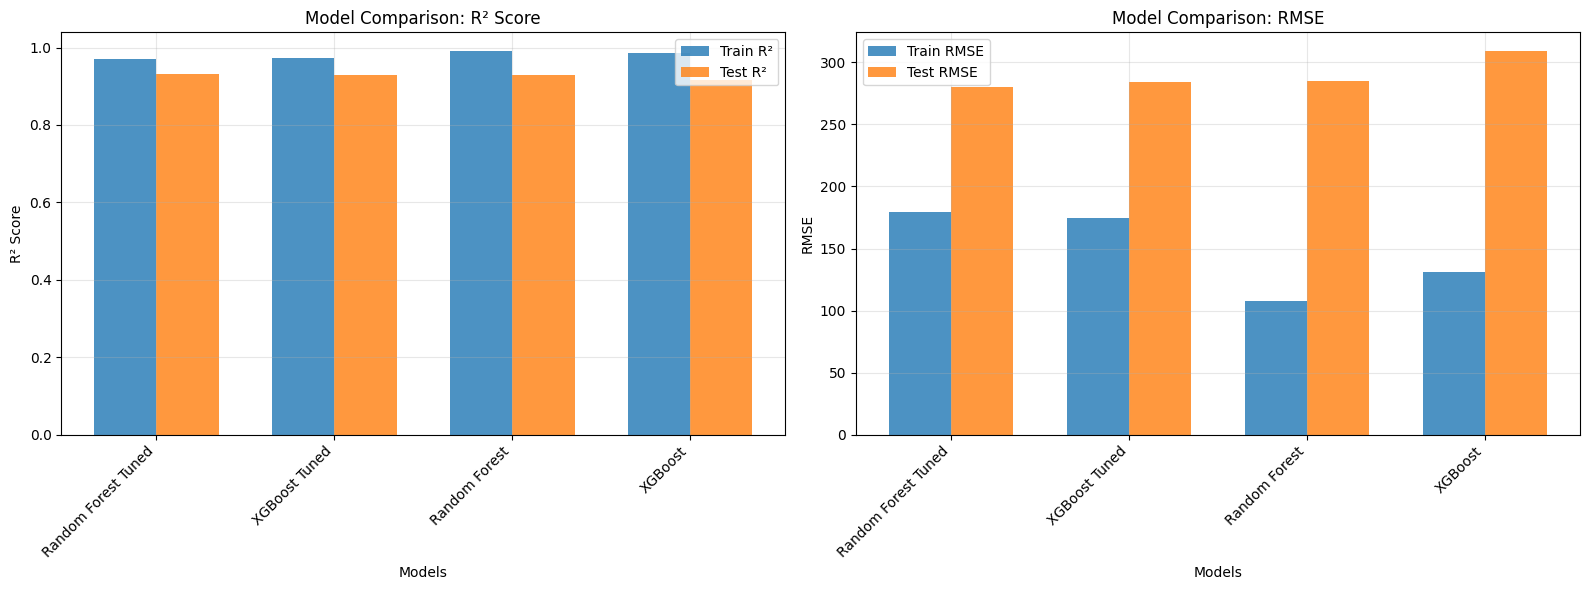


BEST MODEL SELECTED: Random Forest Tuned

Test R²: 0.9312
Test RMSE: 280.24
Test MAE: 104.43
Test MAPE: 0.0375

Best model saved as: superkart_sales_model.pkl
Feature information saved as: feature_info.pkl


In [32]:
# Compare all models
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

comparison_data = []
for model_name, perf in performance.items():
    comparison_data.append({
        'Model': model_name,
        'Train R²': perf['train']['R-squared'].values[0],
        'Test R²': perf['test']['R-squared'].values[0],
        'Train RMSE': perf['train']['RMSE'].values[0],
        'Test RMSE': perf['test']['RMSE'].values[0],
        'Test MAE': perf['test']['MAE'].values[0],
        'Test MAPE': perf['test']['MAPE'].values[0]
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test R²', ascending=False)
print("\n", comparison_df)

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
x_pos = np.arange(len(comparison_df))
width = 0.35
axes[0].bar(x_pos - width/2, comparison_df['Train R²'], width, label='Train R²', alpha=0.8)
axes[0].bar(x_pos + width/2, comparison_df['Test R²'], width, label='Test R²', alpha=0.8)
axes[0].set_xlabel('Models')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison: R² Score')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RMSE comparison
axes[1].bar(x_pos - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[1].bar(x_pos + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[1].set_xlabel('Models')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Comparison: RMSE')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Select the best model based on Test R²
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n" + "="*80)
print(f"BEST MODEL SELECTED: {best_model_name}")
print("="*80)
print(f"\nTest R²: {comparison_df.iloc[0]['Test R²']:.4f}")
print(f"Test RMSE: {comparison_df.iloc[0]['Test RMSE']:.2f}")
print(f"Test MAE: {comparison_df.iloc[0]['Test MAE']:.2f}")
print(f"Test MAPE: {comparison_df.iloc[0]['Test MAPE']:.4f}")

# Serialize the best model
model_filename = 'superkart_sales_model.pkl'
joblib.dump(best_model, model_filename)
print(f"\nBest model saved as: {model_filename}")

# Also save the feature names for later use
feature_info = {
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'all_features': list(X.columns)
}
joblib.dump(feature_info, 'feature_info.pkl')
print("Feature information saved as: feature_info.pkl")

# **Deployment - Backend**

## Flask Web Framework


In [33]:
# Create backend_files directory
os.makedirs('backend_files', exist_ok=True)

# Flask application code
flask_app_code = '''from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np
from flask_cors import CORS

app = Flask(__name__)
CORS(app)

# Load the model and feature info
model = joblib.load('superkart_sales_model.pkl')
feature_info = joblib.load('feature_info.pkl')

@app.route('/')
def home():
    return jsonify({
        'message': 'SuperKart Sales Prediction API',
        'status': 'active',
        'endpoints': {
            '/predict': 'POST - Make single prediction',
            '/predict_batch': 'POST - Make batch predictions'
        }
    })

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.json

        # Convert to DataFrame
        df = pd.DataFrame([data])

        # Make prediction
        prediction = model.predict(df)

        return jsonify({
            'prediction': float(prediction[0]),
            'status': 'success'
        })

    except Exception as e:
        return jsonify({
            'error': str(e),
            'status': 'error'
        }), 400

@app.route('/predict_batch', methods=['POST'])
def predict_batch():
    try:
        data = request.json

        # Convert to DataFrame
        df = pd.DataFrame(data)

        # Make predictions
        predictions = model.predict(df)

        return jsonify({
            'predictions': predictions.tolist(),
            'count': len(predictions),
            'status': 'success'
        })

    except Exception as e:
        return jsonify({
            'error': str(e),
            'status': 'error'
        }), 400

@app.route('/features', methods=['GET'])
def get_features():
    return jsonify(feature_info)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=8000, debug=True)
'''

# Write Flask app
with open('backend_files/app.py', 'w') as f:
    f.write(flask_app_code)

print("Flask application created successfully!")
print("File saved as: backend_files/app.py")

Flask application created successfully!
File saved as: backend_files/app.py


## Dependencies File

In [34]:
# Requirements file for backend
backend_requirements = '''flask==3.0.0
flask-cors==4.0.0
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4
'''

with open('backend_files/requirements.txt', 'w') as f:
    f.write(backend_requirements)

print("Backend requirements file created successfully!")
print("File saved as: backend_files/requirements.txt")

Backend requirements file created successfully!
File saved as: backend_files/requirements.txt


## Dockerfile

In [35]:
# Dockerfile for backend
backend_dockerfile = '''FROM python:3.9-slim

WORKDIR /app

COPY . .

RUN pip3 install -r requirements.txt

EXPOSE 8000

CMD ["python", "app.py"]
'''

with open('backend_files/Dockerfile', 'w') as f:
    f.write(backend_dockerfile)

print("Backend Dockerfile created successfully!")
print("File saved as: backend_files/Dockerfile")

Backend Dockerfile created successfully!
File saved as: backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [36]:
# README for Hugging Face Space (Backend)
backend_readme = '''---
title: SuperKart Sales Prediction API
emoji: 🛒
colorFrom: blue
colorTo: green
sdk: docker
app_port: 8000
---

# SuperKart Sales Prediction API

This is the backend API for SuperKart sales forecasting.

## Endpoints

- `/` - API information
- `/predict` - Make single prediction
- `/predict_batch` - Make batch predictions
- `/features` - Get feature information
'''

with open('backend_files/README.md', 'w') as f:
    f.write(backend_readme)

print("Backend README created successfully!")
print("File saved as: backend_files/README.md")

Backend README created successfully!
File saved as: backend_files/README.md


## Uploading Files to Hugging Face Space (Docker Space)

In [37]:
# Copy model files to backend directory
import shutil

shutil.copy('superkart_sales_model.pkl', 'backend_files/superkart_sales_model.pkl')
shutil.copy('feature_info.pkl', 'backend_files/feature_info.pkl')

print("Model files copied to backend_files directory!")
print("\nTo deploy to Hugging Face:")
print("1. Create a new Space on Hugging Face (select Docker as SDK)")
print("2. Clone the repository")
print("3. Copy all files from backend_files/ to the repository")
print("4. Push to Hugging Face")
print("\nAlternatively, you can upload files manually through the Hugging Face web interface.")

Model files copied to backend_files directory!

To deploy to Hugging Face:
1. Create a new Space on Hugging Face (select Docker as SDK)
2. Clone the repository
3. Copy all files from backend_files/ to the repository
4. Push to Hugging Face

Alternatively, you can upload files manually through the Hugging Face web interface.


# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [18]:
# Create frontend_files directory
os.makedirs('frontend_files', exist_ok=True)

# Streamlit application code
streamlit_app_code = '''import streamlit as st
import requests
import pandas as pd
import json

st.set_page_config(
    page_title="SuperKart Sales Predictor",
    page_icon="🛒",
    layout="wide"
)

# Backend API URL - Update this with your deployed backend URL
API_URL = "YOUR_BACKEND_URL_HERE"  # Replace with your actual backend URL

st.title("🛒 SuperKart Sales Forecasting")
st.markdown("### Predict sales revenue for products across different stores")

# Sidebar for input method selection
st.sidebar.header("Input Method")
input_method = st.sidebar.radio(
    "Choose input method:",
    ["Single Prediction", "Batch Prediction (CSV)"]
)

if input_method == "Single Prediction":
    st.header("Single Product Prediction")

    col1, col2 = st.columns(2)

    with col1:
        product_weight = st.number_input("Product Weight (kg)", min_value=0.0, max_value=50.0, value=12.0, step=0.1)
        product_sugar = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        product_area = st.number_input("Product Allocated Area (ratio)", min_value=0.0, max_value=1.0, value=0.05, step=0.01)
        product_type = st.selectbox(
            "Product Type",
            ["Frozen Foods", "Dairy", "Canned", "Baking Goods", "Health and Hygiene",
             "Snack Foods", "Meat", "Household", "Hard Drinks", "Fruits and Vegetables",
             "Breads", "Soft Drinks", "Starchy Foods", "Breakfast", "Seafood", "Others"]
        )
        product_mrp = st.number_input("Product MRP ($)", min_value=0.0, max_value=500.0, value=150.0, step=1.0)

    with col2:
        store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
        store_location = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
        store_type = st.selectbox(
            "Store Type",
            ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"]
        )
        store_age = st.number_input("Store Age (years)", min_value=0, max_value=50, value=15, step=1)

    if st.button("Predict Sales", type="primary"):
        # Prepare input data
        input_data = {
            "Product_Weight": product_weight,
            "Product_Sugar_Content": product_sugar,
            "Product_Allocated_Area": product_area,
            "Product_Type": product_type,
            "Product_MRP": product_mrp,
            "Store_Size": store_size,
            "Store_Location_City_Type": store_location,
            "Store_Type": store_type,
            "Store_Age": store_age
        }

        try:
            # Make API request
            response = requests.post(f"{API_URL}/predict", json=input_data)

            if response.status_code == 200:
                result = response.json()
                prediction = result['prediction']

                st.success("Prediction Successful!")
                st.metric(
                    label="Predicted Sales Revenue",
                    value=f"${prediction:,.2f}"
                )
            else:
                st.error(f"Error: {response.json().get('error', 'Unknown error')}")

        except Exception as e:
            st.error(f"Connection Error: {str(e)}")
            st.info("Please ensure the backend API is running and the URL is correct.")

else:  # Batch Prediction
    st.header("Batch Prediction from CSV")

    st.markdown("""
    Upload a CSV file with the following columns:
    - Product_Weight
    - Product_Sugar_Content
    - Product_Allocated_Area
    - Product_Type
    - Product_MRP
    - Store_Size
    - Store_Location_City_Type
    - Store_Type
    - Store_Age
    """)

    uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

    if uploaded_file is not None:
        try:
            df = pd.read_csv(uploaded_file)
            st.write("Preview of uploaded data:")
            st.dataframe(df.head())

            if st.button("Predict Sales for All Rows", type="primary"):
                # Convert DataFrame to list of dictionaries
                data = df.to_dict('records')

                try:
                    # Make API request
                    response = requests.post(f"{API_URL}/predict_batch", json=data)

                    if response.status_code == 200:
                        result = response.json()
                        predictions = result['predictions']

                        # Add predictions to DataFrame
                        df['Predicted_Sales'] = predictions

                        st.success(f"Predictions completed for {len(predictions)} rows!")

                        # Display statistics
                        col1, col2, col3 = st.columns(3)
                        with col1:
                            st.metric("Total Predicted Sales", f"${sum(predictions):,.2f}")
                        with col2:
                            st.metric("Average Predicted Sales", f"${sum(predictions)/len(predictions):,.2f}")
                        with col3:
                            st.metric("Number of Products", len(predictions))

                        st.write("Results:")
                        st.dataframe(df)

                        # Download button
                        csv = df.to_csv(index=False)
                        st.download_button(
                            label="Download Predictions as CSV",
                            data=csv,
                            file_name="superkart_predictions.csv",
                            mime="text/csv"
                        )
                    else:
                        st.error(f"Error: {response.json().get('error', 'Unknown error')}")

                except Exception as e:
                    st.error(f"Connection Error: {str(e)}")
                    st.info("Please ensure the backend API is running and the URL is correct.")

        except Exception as e:
            st.error(f"Error reading CSV file: {str(e)}")

# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center'>
    <p>SuperKart Sales Forecasting System</p>
    <p>Powered by Machine Learning</p>
</div>
""", unsafe_allow_html=True)
'''

# Write Streamlit app
with open('frontend_files/app.py', 'w') as f:
    f.write(streamlit_app_code)

print("Streamlit application created successfully!")
print("File saved as: frontend_files/app.py")
print("\nIMPORTANT: Remember to update the API_URL in the app.py file with your deployed backend URL!")

## Dependencies File

## DockerFile

In [19]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


FileNotFoundError: [Errno 2] No such file or directory: 'frontend_files/Dockerfile'

## Uploading Files to Hugging Face Space (Streamlit Space)

# **Actionable Insights and Business Recommendations**

-

-